In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("titanic.csv")

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
#getting info from the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
# Checking for missing values
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
# Checking for the shape of the entire dataset
df.shape

(891, 12)

In [7]:
# checking to see the percentage of those who had cabin or not to see the importance of the information
df['Has_Cabin'] = df['Cabin'].notnull().astype(int)

In [8]:
# The analysis is actually important, I actually need this info
analysis = df.groupby(['Pclass', 'Has_Cabin'])['Survived'].mean()
print(analysis)

Pclass  Has_Cabin
1       0            0.475000
        1            0.664773
2       0            0.440476
        1            0.812500
3       0            0.235908
        1            0.500000
Name: Survived, dtype: float64


In [9]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Has_Cabin        0
dtype: int64

In [10]:
# Creating another column for Cabin
df['Has_Cabin'] = df['Cabin'].notnull().astype(int)

In [11]:
# Dropping the cabin column since it has more than half missing values
df.drop(columns=['Cabin'], inplace=True)

In [12]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
Has_Cabin        0
dtype: int64

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
 11  Has_Cabin    891 non-null    int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 83.7+ KB


In [14]:
#@ Filling up the age missing values with the median
df['Age'] = df['Age'].fillna(df['Age'].median())

In [15]:
# Filling the 2 embarked missing values with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

C:\Users\New\AppData\Local\Temp\ipykernel_44236\3744086084.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [21]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,1


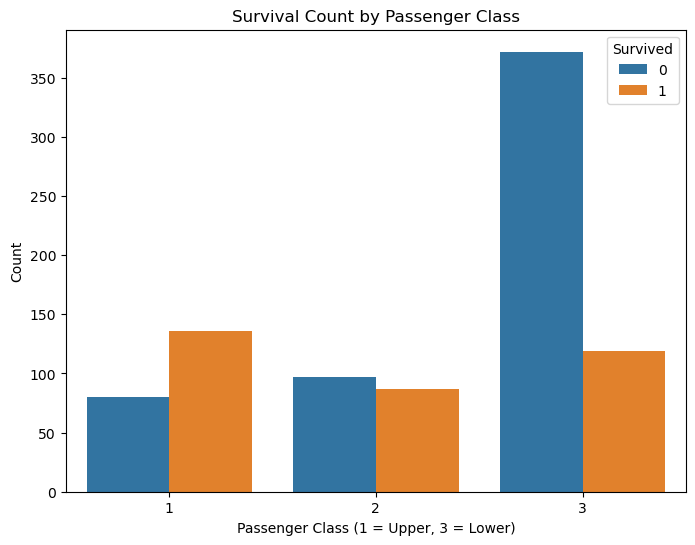

In [17]:
# Visualizing Survival by class with countplot
plt.figure(figsize=(8,6))
sns.countplot(x='Pclass', hue='Survived', data=df)

plt.title("Survival Count by Passenger Class")
plt.xlabel("Passenger Class (1 = Upper, 3 = Lower)")
plt.ylabel("Count")

plt.show()

In [16]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Has_Cabin      0
dtype: int64

The visualization shows a clear relationship between passenger class and survival. First-class passengers had the highest survival rates, with more survivors than fatalities. Second-class passengers had a relatively balanced survival outcome, while third-class passengers experienced significantly higher fatalities than survivals. This indicates that socio-economic status played a major role in survival, with higher-class passengers having better access to safety and evacuation opportunities.

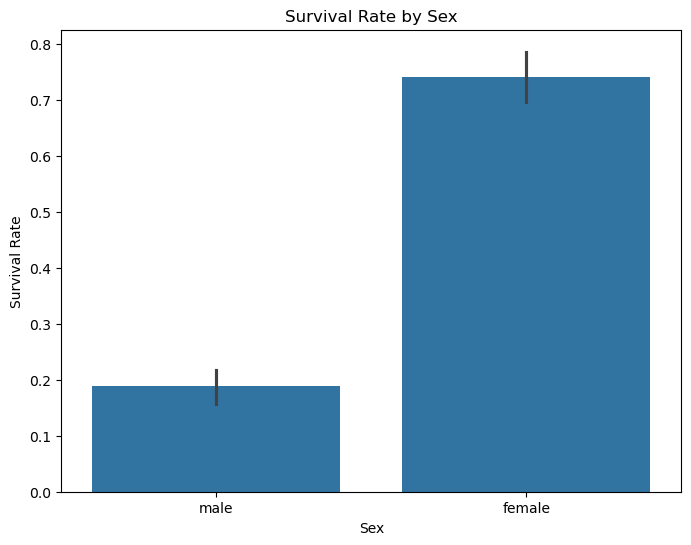

In [18]:
# Visualizing Survival by Sex with barplot
plt.figure(figsize=(8,6))
sns.barplot(x='Sex', y='Survived', data=df)

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")

plt.show()

The barplot shows a significant difference in survival rates between males and females. Approximately 74% of female passengers survived, compared to only about 19% of male passengers. This indicates that gender played a crucial role in survival, with females being far more likely to survive, likely due to evacuation policies such as prioritizing women and children.

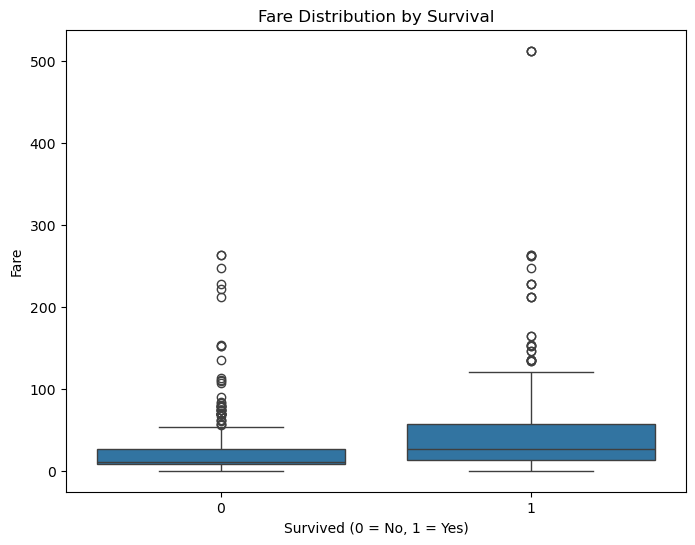

In [19]:
# Visualizing Fare vs Survival with boxplot
plt.figure(figsize=(8,6))
sns.boxplot(x='Survived', y='Fare', data=df)

plt.title("Fare Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Fare")

plt.show()

The boxplot shows that passengers who survived generally paid higher fares compared to those who did not survive. The median fare for survivors is significantly higher, and the distribution extends to much higher values, indicating the presence of high-paying passengers among survivors. This suggests that socio-economic status played a key role in survival, with wealthier passengers having better access to safety measures and evacuation opportunities.

The analysis shows that survival on the Titanic was strongly influenced by socio-economic and demographic factors. Passengers in higher classes, those who paid higher fares, and female passengers had significantly higher survival rates. This indicates that both wealth and social norms played a major role in determining survival outcomes during the disaster.